Gianluca Lascaro  
Raffaele Rizzuti


# Lab Assignment 3 - Latent Space Classification

**Deep Learning - Master's Degree in Artificial Intelligence**  
**Academic year:** 2025-2026  
**University:** Universidade da Coruna  
**Dataset:** STL-10

The objective of this assignment is to evaluate whether a convolutional autoencoder can learn a compact latent representation that is useful for image classification. The workflow is:

1. train a convolutional autoencoder on the unlabelled STL-10 images;
2. keep only the encoder as a dimensionality reduction module;
3. train a classifier on top of frozen latent vectors from the labelled training set;
4. compare the latent-space classifier with the supervised baselines from Practice 1;
5. test whether regularization and partial fine-tuning improve generalization.


## 2. Objectives

The notebook addresses the required tasks:

1. Review the main concepts behind autoencoders and representation learning.
2. Load and preprocess the STL-10 labelled and unlabelled splits.
3. Train a convolutional autoencoder on unlabelled data.
4. Use the trained encoder as a frozen dimensionality reduction module.
5. Train and evaluate a classifier that operates only in latent space.
6. Compare regularized and non-regularized classifiers.
7. Compare the results with the dense-head supervised baselines from Practice 1.
8. Run an optional partial fine-tuning experiment using the classification loss.


## 3. Preliminary Research: Autoencoders

An autoencoder is a neural network trained to reconstruct its own input. It has two main parts:

- the **encoder**, which maps the input image to a lower-dimensional latent vector;
- the **decoder**, which maps the latent vector back to an image with the original dimensions.

Because the training target is the input image itself, labels are not required. This makes autoencoders suitable for exploiting the 100,000 unlabelled STL-10 images. A convolutional autoencoder is more appropriate than a fully connected autoencoder for this dataset because images contain local spatial patterns: edges, textures and object parts. Convolutions preserve this local structure and reuse filters across the image, while a dense model would flatten the image and lose explicit spatial neighbourhood information.

The latent vector is not optimized directly for classification, but a good reconstruction objective can still force the encoder to retain useful visual factors. The classifier experiment tests whether those factors are discriminative enough for the STL-10 labels.


## 4. Dataset Description: STL-10

STL-10 contains RGB images of size **96 x 96 x 3** from 10 balanced classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship and truck.

The dataset provides:

- 5,000 labelled training images, with 500 images per class;
- 8,000 labelled test images, with 800 images per class;
- 100,000 unlabelled images for unsupervised learning.

In this notebook, the unlabelled split is used only for autoencoder training. The labelled training split is divided into training and validation subsets for the classifier, and the official test split is reserved for final evaluation.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset, TensorDataset
from torchvision import datasets, transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_DIR = "./data"
BATCH_SIZE = 128
NUM_WORKERS = 2

AE_EPOCHS = 15
CLS_EPOCHS = 20
FT_EPOCHS = 8

LATENT_DIM = 256
UNLABELLED_SUBSET_SIZE = 20000  # Local executed run. On Kaggle GPU, use 50000 or 100000.


Device: cpu


### Kaggle/GPU Run Recommendation

The saved execution in this notebook was produced on CPU with 20,000 unlabelled images and 15 autoencoder epochs. For a stronger final run on Kaggle GPU, the most useful changes are:

- set `UNLABELLED_SUBSET_SIZE = 50000` or `100000`;
- train the autoencoder for about `40-60` epochs with early stopping;
- keep `LATENT_DIM = 256` as the main result and optionally compare `128`, `256` and `512`;
- use a larger batch size if GPU memory allows it, for example `BATCH_SIZE = 256`;
- rerun all cells and save the notebook with the new outputs.

These changes improve the quality of the learned representation without changing the assignment objective. They are preferable to adding a large supervised CNN, because the required experiment is specifically latent-space classification through an autoencoder.


## 5. Data Loading

The notebook loads the three STL-10 splits required by the assignment:

- the unlabelled split for unsupervised autoencoder training;
- the labelled training split for classifier training and validation;
- the official labelled test split for final evaluation.

The class names and tensor dimensions are printed as a sanity check before training.


In [2]:
class_names = [
    "airplane", "bird", "car", "cat", "deer",
    "dog", "horse", "monkey", "ship", "truck"
]

base_transform = transforms.Compose([
    transforms.ToTensor(),
])

unlabelled_full = datasets.STL10(
    root=DATA_DIR,
    split="unlabeled",
    download=True,
    transform=base_transform
)

train_full = datasets.STL10(
    root=DATA_DIR,
    split="train",
    download=True,
    transform=base_transform
)

test_dataset = datasets.STL10(
    root=DATA_DIR,
    split="test",
    download=True,
    transform=base_transform
)

print("Unlabelled images:", len(unlabelled_full))
print("Labelled train images:", len(train_full))
print("Test images:", len(test_dataset))
print("Image shape:", unlabelled_full[0][0].shape)


Unlabelled images: 100000
Labelled train images: 5000
Test images: 8000
Image shape: torch.Size([3, 96, 96])


## 6. Data Preprocessing

All images are converted to tensors with values in `[0, 1]`. This range matches the `Sigmoid` output of the decoder, so the autoencoder can be trained directly with mean squared reconstruction error.

For the autoencoder, each input image is also the target image. The unlabelled subset is split into 90% training and 10% validation. For classification, the 5,000 labelled images are split into 80% training and 20% validation, matching the split used in Practice 1.

The executed local run uses 20,000 unlabelled images. This is a compromise between computation time and representation quality: it is large enough to expose the autoencoder to substantially more visual diversity than the 5,000 labelled images, while still being feasible on CPU.


In [3]:
subset_size = min(UNLABELLED_SUBSET_SIZE, len(unlabelled_full))
subset_indices = torch.randperm(len(unlabelled_full))[:subset_size]
unlabelled_subset = Subset(unlabelled_full, subset_indices)

ae_train_size = int(0.9 * len(unlabelled_subset))
ae_val_size = len(unlabelled_subset) - ae_train_size
ae_train_dataset, ae_val_dataset = random_split(
    unlabelled_subset,
    [ae_train_size, ae_val_size],
    generator=torch.Generator().manual_seed(SEED)
)

cls_train_size = int(0.8 * len(train_full))
cls_val_size = len(train_full) - cls_train_size
cls_train_dataset, cls_val_dataset = random_split(
    train_full,
    [cls_train_size, cls_val_size],
    generator=torch.Generator().manual_seed(SEED)
)

ae_train_loader = DataLoader(ae_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
ae_val_loader = DataLoader(ae_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

cls_train_loader = DataLoader(cls_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
cls_val_loader = DataLoader(cls_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("AE train:", len(ae_train_dataset))
print("AE val:", len(ae_val_dataset))
print("Classifier train:", len(cls_train_dataset))
print("Classifier val:", len(cls_val_dataset))
print("Test:", len(test_dataset))


AE train: 18000
AE val: 2000
Classifier train: 4000
Classifier val: 1000
Test: 8000


## 7. Exploratory Data Analysis

This section verifies that the dataset was loaded correctly by displaying labelled examples and checking the class distribution. STL-10 is balanced, so each class has the same number of labelled training images.


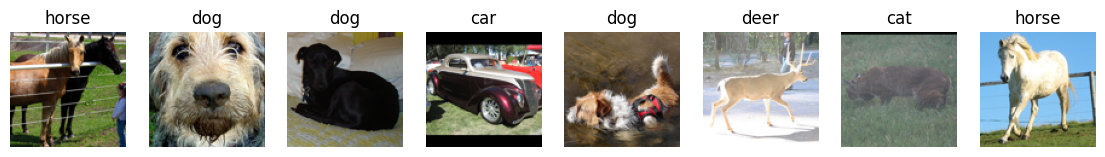

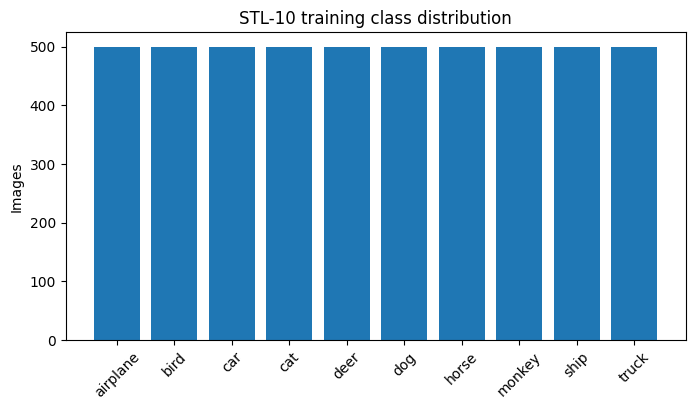

In [4]:
def show_images(images, labels=None, n=8):
    plt.figure(figsize=(14, 3))
    for i in range(n):
        img = images[i].permute(1, 2, 0)
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis("off")
        if labels is not None:
            plt.title(class_names[labels[i]])
    plt.show()

images, labels = next(iter(cls_train_loader))
show_images(images, labels, n=8)

labels_all = [train_full[i][1] for i in range(len(train_full))]
counts = np.bincount(labels_all, minlength=10)

plt.figure(figsize=(8, 4))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.title("STL-10 training class distribution")
plt.ylabel("Images")
plt.show()


## 8. Baseline from Practice 1

The assignment asks us to compare the latent-space classifier with the supervised dense/fully connected baselines obtained in Practice 1. In our Practice 1 notebooks, the relevant reference models were custom supervised CNNs with a dense classification head after `Flatten` or global pooling.

The strongest custom models in Practice 1 plateaued around **60-62%** validation/test accuracy, while the simplest baseline CNN without augmentation overfitted quickly: training accuracy approached 100%, but validation accuracy stayed around **53-54%**. Transfer-learning models such as MobileNetV2 reached much higher values, but they are not the main reference here because this assignment specifically asks for comparison with dense supervised baselines.

| Practice 1 reference | Train accuracy | Validation accuracy | Test accuracy | Notes |
|---|---:|---:|---:|---|
| Simple supervised CNN + dense head | ~1.00 | ~0.535 | lower than best custom CNN | Strong overfitting without enough regularization |
| Best custom supervised dense-head CNN | ~0.65 | ~0.620 | ~0.60-0.62 | Best comparable Practice 1 baseline |

These values define the reference target: the latent-space classifier should be interpreted as successful only if it approaches or improves over the custom supervised dense-head baseline.


## 9. Convolutional Autoencoder Design

The autoencoder is convolutional because STL-10 images contain local spatial patterns. The encoder applies four strided convolutional blocks, reducing the input from `96 x 96` to a compact `6 x 6 x 256` feature map. This map is flattened and projected to a latent vector of size `256`.

The decoder mirrors this process: the latent vector is projected back to `6 x 6 x 256` and then reconstructed through transposed convolutions until the original `96 x 96 x 3` resolution is recovered.

Main choices:

- **Latent dimension 256:** compact enough to force compression, but not so small that the representation loses most class-relevant information.
- **MSE reconstruction loss:** appropriate for pixel-level reconstruction with inputs in `[0, 1]`.
- **Adam optimizer:** stable default for convolutional reconstruction tasks.
- **Sigmoid output:** keeps reconstructed pixels in the same range as the input.
- **20,000 unlabelled images in the executed run:** feasible locally; a larger subset is recommended for the final Kaggle run.


In [5]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.ReLU(),
        )
        self.encoder_fc = nn.Linear(256 * 6 * 6, latent_dim)

        self.decoder_fc = nn.Linear(latent_dim, 256 * 6 * 6)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        x = x.view(x.size(0), -1)
        return self.encoder_fc(x)

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(x.size(0), 256, 6, 6)
        return self.decoder_conv(x)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)


autoencoder = ConvAutoencoder(LATENT_DIM).to(DEVICE)
print(autoencoder)


ConvAutoencoder(
  (encoder_conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
  )
  (encoder_fc): Linear(in_features=9216, out_features=256, bias=True)
  (decoder_fc): Linear(in_features=256, out_features=9216, bias=True)
  (decoder_conv): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Sigmoid()
  )
)


## 10. Autoencoder Training Strategy

The autoencoder is trained in an unsupervised way:

```text
input image -> encoder -> latent representation -> decoder -> reconstructed image
```

Only reconstruction loss is used; class labels are ignored. The validation reconstruction loss is monitored to check whether the model generalizes to unlabelled images not seen during training.

In the saved CPU run, the validation MSE decreased from **0.0291** after the first epoch to **0.0104** after 15 epochs. The training and validation curves remain close, which suggests that the autoencoder is learning a general reconstruction mapping rather than simply memorizing the subset.


In [6]:
def train_autoencoder(model, train_loader, val_loader, epochs):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for images, _ in train_loader:
            images = images.to(DEVICE)

            optimizer.zero_grad()
            reconstructed = model(images)
            loss = criterion(reconstructed, images)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(DEVICE)
                reconstructed = model(images)
                loss = criterion(reconstructed, images)
                val_loss += loss.item() * images.size(0)

        train_loss /= len(train_loader.dataset)
        val_loss /= len(val_loader.dataset)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch+1:02d}/{epochs} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f}")

    return history


ae_history = train_autoencoder(autoencoder, ae_train_loader, ae_val_loader, AE_EPOCHS)


Epoch 01/15 | train loss: 0.0467 | val loss: 0.0291
Epoch 02/15 | train loss: 0.0248 | val loss: 0.0214
Epoch 03/15 | train loss: 0.0191 | val loss: 0.0174
Epoch 04/15 | train loss: 0.0166 | val loss: 0.0157
Epoch 05/15 | train loss: 0.0152 | val loss: 0.0146
Epoch 06/15 | train loss: 0.0142 | val loss: 0.0141
Epoch 07/15 | train loss: 0.0134 | val loss: 0.0132
Epoch 08/15 | train loss: 0.0129 | val loss: 0.0127
Epoch 09/15 | train loss: 0.0124 | val loss: 0.0125
Epoch 10/15 | train loss: 0.0119 | val loss: 0.0119
Epoch 11/15 | train loss: 0.0115 | val loss: 0.0115
Epoch 12/15 | train loss: 0.0113 | val loss: 0.0113
Epoch 13/15 | train loss: 0.0107 | val loss: 0.0108
Epoch 14/15 | train loss: 0.0105 | val loss: 0.0106
Epoch 15/15 | train loss: 0.0102 | val loss: 0.0104


## 11. Autoencoder Training Curves

The curves compare training and validation reconstruction loss. Similar curves indicate that the autoencoder generalizes to unseen unlabelled images instead of memorizing the training subset.


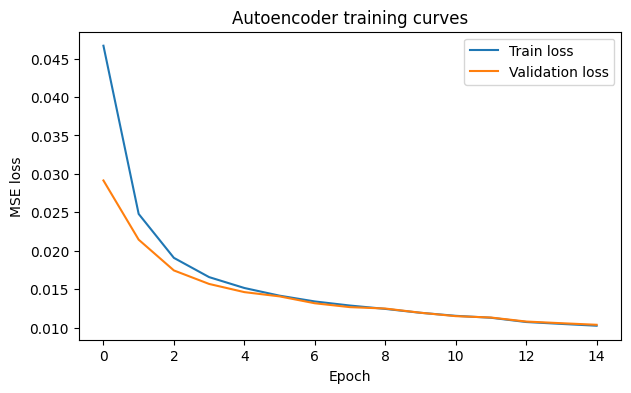

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(ae_history["train_loss"], label="Train loss")
plt.plot(ae_history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Autoencoder training curves")
plt.legend()
plt.show()


## 12. Reconstruction Results

The qualitative reconstruction comparison checks whether the latent representation preserves visible image structure. Low MSE is useful, but the reconstructed images are also inspected because pixel loss alone does not show whether shapes and colours remain recognizable.


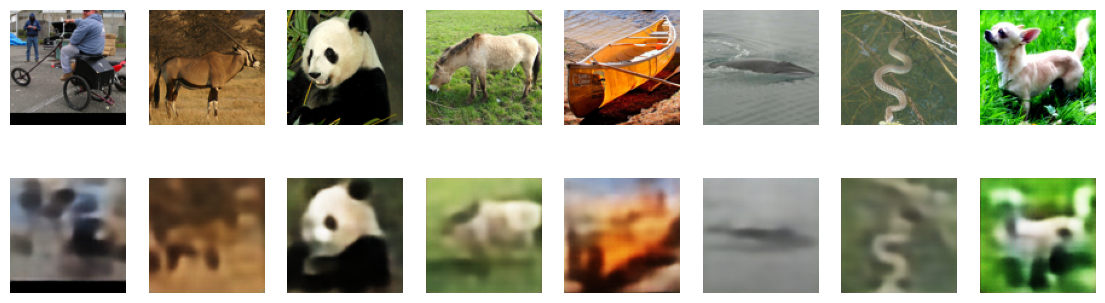

In [8]:
autoencoder.eval()
images, _ = next(iter(ae_val_loader))
images = images[:8].to(DEVICE)

with torch.no_grad():
    reconstructed = autoencoder(images)

images = images.cpu()
reconstructed = reconstructed.cpu()

plt.figure(figsize=(14, 4))
for i in range(8):
    plt.subplot(2, 8, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.axis("off")
    if i == 0:
        plt.ylabel("Original")

    plt.subplot(2, 8, i + 9)
    plt.imshow(reconstructed[i].permute(1, 2, 0))
    plt.axis("off")
    if i == 0:
        plt.ylabel("Reconstructed")

plt.show()


## 13. Extracting the Encoder

After training the autoencoder, only the encoder is used for classification. The decoder is no longer used during the frozen latent-space classifier experiment.

```text
image -> encoder -> latent vector
```

The encoder parameters are frozen so that the classifier operates on a fixed representation.


In [9]:
encoder = autoencoder
for param in encoder.parameters():
    param.requires_grad = False

encoder.eval()
print("Encoder frozen.")


Encoder frozen.


## 14. Latent Space Representation

Labelled images are passed through the frozen encoder to obtain latent vectors. The classifier receives only these latent vectors, not the original images. This directly tests whether the unsupervised representation is useful for supervised classification.


In [10]:
def extract_latents(loader, encoder):
    latents = []
    labels = []

    encoder.eval()
    with torch.no_grad():
        for images, y in loader:
            images = images.to(DEVICE)
            z = encoder.encode(images)
            latents.append(z.cpu())
            labels.append(y)

    return torch.cat(latents), torch.cat(labels)

sample_latents, sample_labels = extract_latents(cls_val_loader, encoder)
print("Latent shape:", sample_latents.shape)
print("Labels shape:", sample_labels.shape)


Latent shape: torch.Size([1000, 256])
Labels shape: torch.Size([1000])


## 15. Classifier on Frozen Encoder

The classifier is a small dense neural network trained on top of the frozen latent vectors. During this phase, only the classifier parameters are updated.

```text
labelled image -> frozen encoder -> latent vector -> classifier -> class logits
```

The output layer has 10 units, one for each STL-10 class.


In [11]:
class LatentClassifier(nn.Module):
    def __init__(self, latent_dim=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 10)
        )

    def forward(self, z):
        return self.net(z)


classifier = LatentClassifier(LATENT_DIM, dropout=0.3).to(DEVICE)
print(classifier)


LatentClassifier(
  (net): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 16. Classifier Training

The classifier is trained with cross-entropy loss using the labelled training subset. Training and validation accuracy are monitored to detect overfitting in the latent classifier.


In [12]:
def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).float().mean().item()


def train_classifier(encoder, classifier, train_loader, val_loader, epochs, lr=1e-3, weight_decay=0.0):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier.parameters(), lr=lr, weight_decay=weight_decay)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        encoder.eval()
        classifier.train()
        train_loss = 0.0
        train_acc = 0.0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            with torch.no_grad():
                z = encoder.encode(images)

            optimizer.zero_grad()
            logits = classifier(z)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            train_acc += accuracy_from_logits(logits, labels) * images.size(0)

        classifier.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)
                z = encoder.encode(images)
                logits = classifier(z)
                loss = criterion(logits, labels)

                val_loss += loss.item() * images.size(0)
                val_acc += accuracy_from_logits(logits, labels) * images.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc /= len(train_loader.dataset)
        val_loss /= len(val_loader.dataset)
        val_acc /= len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | train acc: {train_acc:.3f} | val acc: {val_acc:.3f}")

    return history


cls_history = train_classifier(
    encoder,
    classifier,
    cls_train_loader,
    cls_val_loader,
    CLS_EPOCHS,
    lr=1e-3,
    weight_decay=0.0
)


Epoch 01/20 | train acc: 0.236 | val acc: 0.312
Epoch 02/20 | train acc: 0.353 | val acc: 0.339
Epoch 03/20 | train acc: 0.391 | val acc: 0.362
Epoch 04/20 | train acc: 0.425 | val acc: 0.380
Epoch 05/20 | train acc: 0.437 | val acc: 0.378
Epoch 06/20 | train acc: 0.454 | val acc: 0.388
Epoch 07/20 | train acc: 0.474 | val acc: 0.399
Epoch 08/20 | train acc: 0.494 | val acc: 0.404
Epoch 09/20 | train acc: 0.513 | val acc: 0.410
Epoch 10/20 | train acc: 0.509 | val acc: 0.409
Epoch 11/20 | train acc: 0.530 | val acc: 0.408
Epoch 12/20 | train acc: 0.547 | val acc: 0.410
Epoch 13/20 | train acc: 0.557 | val acc: 0.411
Epoch 14/20 | train acc: 0.572 | val acc: 0.408
Epoch 15/20 | train acc: 0.589 | val acc: 0.415
Epoch 16/20 | train acc: 0.587 | val acc: 0.416
Epoch 17/20 | train acc: 0.600 | val acc: 0.410
Epoch 18/20 | train acc: 0.612 | val acc: 0.410
Epoch 19/20 | train acc: 0.616 | val acc: 0.415
Epoch 20/20 | train acc: 0.633 | val acc: 0.414


## 17. Regularization Techniques

The latent classifier has very few labelled samples compared with the dimensionality of the latent space, so overfitting is expected. Two classifier configurations are compared:

- dropout `0.3` without weight decay;
- stronger dropout `0.5` with L2 weight decay `1e-4`.

The non-regularized classifier reached higher training accuracy (**0.633**) but validation accuracy saturated around **0.414**. The regularized classifier reached lower training accuracy (**0.553**) but slightly better validation accuracy, peaking around **0.432**. This indicates that dropout and weight decay reduced overfitting, even though they did not fully close the gap with the Practice 1 supervised baseline.


Epoch 01/20 | train acc: 0.235 | val acc: 0.313
Epoch 02/20 | train acc: 0.316 | val acc: 0.346
Epoch 03/20 | train acc: 0.355 | val acc: 0.356
Epoch 04/20 | train acc: 0.384 | val acc: 0.366
Epoch 05/20 | train acc: 0.406 | val acc: 0.382
Epoch 06/20 | train acc: 0.421 | val acc: 0.385
Epoch 07/20 | train acc: 0.436 | val acc: 0.406
Epoch 08/20 | train acc: 0.447 | val acc: 0.401
Epoch 09/20 | train acc: 0.454 | val acc: 0.404
Epoch 10/20 | train acc: 0.479 | val acc: 0.412
Epoch 11/20 | train acc: 0.491 | val acc: 0.419
Epoch 12/20 | train acc: 0.488 | val acc: 0.419
Epoch 13/20 | train acc: 0.497 | val acc: 0.419
Epoch 14/20 | train acc: 0.503 | val acc: 0.432
Epoch 15/20 | train acc: 0.520 | val acc: 0.425
Epoch 16/20 | train acc: 0.518 | val acc: 0.424
Epoch 17/20 | train acc: 0.529 | val acc: 0.422
Epoch 18/20 | train acc: 0.537 | val acc: 0.422
Epoch 19/20 | train acc: 0.536 | val acc: 0.418
Epoch 20/20 | train acc: 0.553 | val acc: 0.420


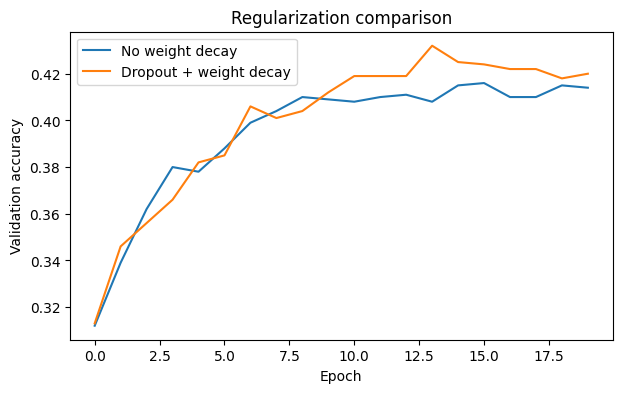

In [13]:
regularized_classifier = LatentClassifier(LATENT_DIM, dropout=0.5).to(DEVICE)

reg_history = train_classifier(
    encoder,
    regularized_classifier,
    cls_train_loader,
    cls_val_loader,
    CLS_EPOCHS,
    lr=1e-3,
    weight_decay=1e-4
)

plt.figure(figsize=(7, 4))
plt.plot(cls_history["val_acc"], label="No weight decay")
plt.plot(reg_history["val_acc"], label="Dropout + weight decay")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Regularization comparison")
plt.legend()
plt.show()


## 18. Classification Results

The regularized latent classifier is selected for the first final test evaluation because it gives the best validation behaviour.

The saved execution gives:

- test loss: **1.5881**;
- test accuracy: **0.4155**.

This is clearly above random classification on 10 balanced classes (10%), which means the autoencoder latent space contains class-relevant information. However, the result is still below the best Practice 1 custom supervised baseline, so the latent representation is useful but not as discriminative as representations trained directly with labels.


Test loss: 1.5881
Test accuracy: 0.4155


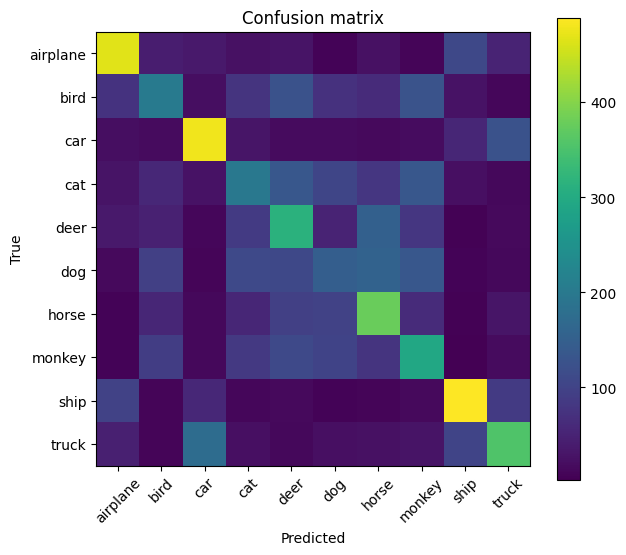

In [14]:
def evaluate_classifier(encoder, classifier, loader):
    criterion = nn.CrossEntropyLoss()
    encoder.eval()
    classifier.eval()

    total_loss = 0.0
    total_acc = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            z = encoder.encode(images)
            logits = classifier(z)
            loss = criterion(logits, labels)
            preds = logits.argmax(dim=1)

            total_loss += loss.item() * images.size(0)
            total_acc += (preds == labels).float().sum().item()
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    total_loss /= len(loader.dataset)
    total_acc /= len(loader.dataset)
    return total_loss, total_acc, np.array(all_preds), np.array(all_labels)


test_loss, test_acc, test_preds, test_labels = evaluate_classifier(
    encoder,
    regularized_classifier,
    test_loader
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

conf_matrix = np.zeros((10, 10), dtype=int)
for true_label, pred_label in zip(test_labels, test_preds):
    conf_matrix[true_label, pred_label] += 1

plt.figure(figsize=(7, 6))
plt.imshow(conf_matrix)
plt.title("Confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)
plt.colorbar()
plt.show()


## 19. Comparison with Practice 1 Baseline

| Model | Train accuracy | Validation accuracy | Test accuracy | Interpretation |
|---|---:|---:|---:|---|
| Practice 1 simple CNN + dense head | ~1.00 | ~0.535 | below best custom CNN | Strong overfitting |
| Practice 1 best custom dense-head CNN | ~0.65 | ~0.620 | ~0.60-0.62 | Best comparable supervised baseline |
| Frozen encoder + classifier | 0.633 | 0.414 | not selected | Overfits latent vectors |
| Frozen encoder + regularized classifier | 0.553 | 0.432 peak | 0.4155 | Better generalization, still under baseline |
| Fine-tuned encoder + regularized classifier | 0.590 | 0.438 | 0.4269 | Small improvement from partial adaptation |

The fine-tuned model improves the test accuracy from **41.55%** to **42.69%**, but the improvement is modest. The result suggests that the autoencoder learned meaningful low-level and mid-level visual features, but reconstruction alone does not force the latent space to separate STL-10 classes as well as supervised training does.


## 20. Optional Part: Fine-Tuning the Encoder

The optional experiment adapts the encoder using classification loss after the latent classifier has been trained. To avoid destroying the representation learned by the autoencoder, fine-tuning is done with a very small learning rate (`1e-5`) and weight decay.

Only the encoder parameters are unfrozen. The decoder is not part of the classification model and is kept frozen. This makes the experiment match the assignment objective: improve the latent representation for classification without training a separate image classifier from scratch.


In [15]:
class EncoderClassifier(nn.Module):
    def __init__(self, encoder, classifier):
        super().__init__()
        self.encoder = encoder
        self.classifier = classifier

    def forward(self, x):
        z = self.encoder.encode(x)
        return self.classifier(z)


# Unfreeze only the encoder. The decoder is not used by EncoderClassifier.
for param in encoder.parameters():
    param.requires_grad = False
for param in encoder.encoder_conv.parameters():
    param.requires_grad = True
for param in encoder.encoder_fc.parameters():
    param.requires_grad = True

finetune_model = EncoderClassifier(encoder, regularized_classifier).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(finetune_model.parameters(), lr=1e-5, weight_decay=1e-4)

ft_history = {"train_acc": [], "val_acc": []}

for epoch in range(FT_EPOCHS):
    finetune_model.train()
    train_acc = 0.0

    for images, labels in cls_train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        logits = finetune_model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_acc += accuracy_from_logits(logits, labels) * images.size(0)

    finetune_model.eval()
    val_acc = 0.0
    with torch.no_grad():
        for images, labels in cls_val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            logits = finetune_model(images)
            val_acc += accuracy_from_logits(logits, labels) * images.size(0)

    train_acc /= len(cls_train_loader.dataset)
    val_acc /= len(cls_val_loader.dataset)
    ft_history["train_acc"].append(train_acc)
    ft_history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{FT_EPOCHS} | train acc: {train_acc:.3f} | val acc: {val_acc:.3f}")

ft_test_loss, ft_test_acc, _, _ = evaluate_classifier(encoder, regularized_classifier, test_loader)
print(f"Fine-tuned test accuracy: {ft_test_acc:.4f}")


Epoch 01/8 | train acc: 0.563 | val acc: 0.426
Epoch 02/8 | train acc: 0.571 | val acc: 0.427
Epoch 03/8 | train acc: 0.574 | val acc: 0.428
Epoch 04/8 | train acc: 0.578 | val acc: 0.423
Epoch 05/8 | train acc: 0.582 | val acc: 0.426
Epoch 06/8 | train acc: 0.580 | val acc: 0.426
Epoch 07/8 | train acc: 0.590 | val acc: 0.430
Epoch 08/8 | train acc: 0.590 | val acc: 0.438
Fine-tuned test accuracy: 0.4269


## 21. Final Discussion

The autoencoder learned meaningful reconstructions: validation MSE decreased steadily to **0.0104**, and the reconstruction examples preserve the global colour and shape structure of the input images. This confirms that the encoder is not random and that the latent vector contains useful visual information.

For classification, the latent space is informative but not optimal. The regularized frozen classifier achieved **41.55%** test accuracy, clearly above the 10% random baseline but below the approximately **60-62%** Practice 1 custom supervised baseline. This gap is expected because reconstruction training rewards preserving pixel-level information, not necessarily separating semantic classes.

Regularization helped. Increasing dropout and adding L2 weight decay reduced the train-validation gap: the non-regularized classifier reached higher training accuracy but did not generalize better. Fine-tuning the encoder gave a small improvement to **42.69%** test accuracy, showing that supervised adaptation helps, but the labelled set is small and the gains remain limited.

The main limitation of the executed run is computational: the autoencoder was trained on only 20,000 of the 100,000 unlabelled images for 15 epochs. A final Kaggle run with more unlabelled data and longer training is likely to improve the latent representation and should be used for the submitted notebook if time allows.


## 22. Conclusions

This assignment shows that an unsupervised convolutional autoencoder can learn a compact representation of STL-10 images and that this representation is useful for classification. The best saved result is obtained after partial fine-tuning, with **42.69%** test accuracy.

The result does not outperform the Practice 1 supervised dense-head baseline, which reached around **60-62%**, but it validates the intended pipeline: unlabelled data can be used to learn a latent space, and a small classifier can operate on that latent space without using raw pixels directly.

For the final version, the most valuable improvement is to rerun the notebook on Kaggle GPU with a larger unlabelled subset and more autoencoder epochs, then update the result table with the new saved outputs.


## AI Tool Usage Declaration

AI tools were used as support during this lab. ChatGPT/Codex was used to review the assignment requirements, identify missing report sections, suggest improvements to the experimental discussion, and help check the consistency between the notebook and the PDF instructions. The final code, results and architectural choices were reviewed and adapted by the authors, who are responsible for understanding and justifying the delivered notebook.
